hjm pca simulator + comparison with historical

# HJM-PCA Yield Curve Simulator
## Exact replication of Mueller (2022) Master Thesis — Section 2.2.2
### *Deep Treasury Management for Banks*

---

### What the thesis specifies (Section 2.2.2, steps 1–5 + Eq. 20–21)

| Step | Thesis text |
|------|-------------|
| **1** | Estimate covariance Σ̂ of **weekly** forward curve changes ΔFₜ, annualise ×52 |
| **2** | Eigendecomposition: Σ̂ = QΛQ⁻¹ |
| **3** | Keep d=3, scale: **Ṽ⁽ʲ⁾ := λⱼ · Q⁽ʲ⁾** *(thesis notation — see Note A below)* |
| **4** | Fit **cubic polynomial** to each Ṽ⁽ʲ⁾ as function of tenor (regularisation) |
| **5** | V⁽ʲ⁾ = polynomial evaluated at tenor grid |
| **Drift** | A(τ) = σ(τ) ∫₀^τ σ(s)ᵀ ds — trapezoid rule (Eq. 15 / Eq. 20) |
| **Sim** | F_{t+Δt} = Fₜ + (A + ∂Fₜ/∂τ)Δt + V·ΔW  (Eq. 20) |
| **Discount** | Dᵏₜ = exp(−Σⱼ≤ₖ Fʲₜ Δτ)  (Eq. 21) |

### Note A — Notation inconsistency in Step 3
The thesis writes `λⱼ · Q⁽ʲ⁾` but Figure 3 shows loadings in the **±0.005 range**.  
Numerical check with our data:
- `λⱼ · Q⁽ʲ⁾` → range ±0.0002  ✗ (too small by ~25×)
- `√λⱼ · Q⁽ʲ⁾` → range ±0.006  ✓ (matches Figure 3)

This is a common notational shortcut in the literature where "scale by eigenvalue" 
informally means "scale by the factor that gives the correct volatility unit", i.e. √λ.
**Both versions are implemented below so you can verify directly.**

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

np.random.seed(250221)  # matches the ALM notebook seed

# ── Hyperparameters (Table 5 / Table 2 of thesis/paper) ───────────────────
N_PC        = 3          # number of principal components
POLY_DEGREE = 3          # cubic polynomials (thesis: "degree 3 for all d")
N_SIM       = 500        # simulated scenarios
T_HORIZON   = 5.0        # years (thesis experiments: 5y and 15y)
dt          = 1 / 12     # monthly ALM steps
n_steps     = int(T_HORIZON / dt)

# Forward curve tenor grid: monthly, 1m → 15y (N=180, matching thesis)
dtau    = 1 / 12
N_TEN   = 180
TENORS  = np.arange(1, N_TEN + 1) * dtau   # shape (180,)

# Observed yield maturities in our dataset
YIELD_COLS = ['Yield_1M','Yield_3M','Yield_6M','Yield_1Y','Yield_2Y',
              'Yield_3Y','Yield_5Y','Yield_7Y','Yield_10Y','Yield_20Y','Yield_30Y']
MAT_LABELS = ['1M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']
MATURITIES = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

print(f"Steps: {n_steps} | Tenors: {N_TEN} | Simulations: {N_SIM}")

Steps: 60 | Tenors: 180 | Simulations: 500


---
## Step 0 — Load Data & Bootstrap Instantaneous Forward Curves

The thesis uses **SNB CHF Svensson-fitted** forward curves. We use US Treasury zero yields
and bootstrap instantaneous forward rates via:
$$f(\tau) = y(\tau) + \tau \cdot \frac{dy}{d\tau}$$
The methodology is identical — only the underlying market differs.

In [98]:
CSV_PATH = 'raw_macro_yield_dataset(in).csv'  #'historical data train.csv' 
CALIBRATION_END = pd.Timestamp('2020-12-31')
GENERATION_DATE = pd.Timestamp('2026-02-20')

df = pd.read_csv(CSV_PATH, parse_dates=['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)
df_valid = df.dropna(subset=YIELD_COLS).copy()

# Calibration sample: use data up to 2020-12-31
df_calib = df_valid[df_valid['DATE'] <= CALIBRATION_END].copy()
yields_obs = df_calib[YIELD_COLS].values / 100.0   # decimal
dates_obs  = df_calib['DATE'].values

# Generation start curve: fixed at 2026-02-20 (fallback: last available)
row_start = df_valid[df_valid['DATE'] == GENERATION_DATE]
if len(row_start) == 0:
    row_start = df_valid.iloc[[-1]]
    print(f"Warning: {GENERATION_DATE.date()} not found; using last available date {row_start.iloc[0]['DATE'].date()}")

start_date_used = row_start.iloc[0]['DATE']
start_yield_curve_exact = row_start[YIELD_COLS].iloc[0].values.copy()  # in %
start_yield_curve_dec   = start_yield_curve_exact / 100.0               # decimal

print(f"Calibration daily observations: {len(yields_obs):,}")
print(f"Calibration period: {str(dates_obs[0])[:10]} → {str(dates_obs[-1])[:10]}")
print(f"Generation start curve date: {start_date_used.date()}")

def yields_to_forward_curve(y_vec, maturities, tenors):
    """
    Convert zero yields at observed maturities to instantaneous forward rates
    on a fine monthly tenor grid.
    f(τ) = y(τ) + τ * dy/dτ  (standard ZCB relationship)
    Uses natural cubic spline interpolation.
    """
    cs  = CubicSpline(maturities, y_vec, bc_type='natural') #Splining means fitting a smooth curve through known data points.

    y   = cs(tenors)
    dydtau = cs(tenors, 1)
    return y + tenors * dydtau

# Build forward curve matrix — shape (N_obs, N_TEN)
print("Bootstrapping forward curves...", end="")
F_all = np.array([yields_to_forward_curve(yields_obs[i], MATURITIES, TENORS)
                  for i in range(len(yields_obs))])
print(f" done. Shape: {F_all.shape}")

# Initial forward curve in simulation: built from the fixed generation start yield curve
F0 = yields_to_forward_curve(start_yield_curve_dec, MATURITIES, TENORS)
print(f"\nInitial forward curve (generation start: {start_date_used.date()}):")
for i, t in enumerate([0, 11, 23, 59, 119, 179]):
    print(f"  tenor {TENORS[t]*12:.0f}m = {F0[t]*100:.4f}%")

Calibration daily observations: 4,754
Calibration period: 2002-01-02 → 2020-12-31
Generation start curve date: 2026-02-20
Bootstrapping forward curves... done. Shape: (4754, 180)

Initial forward curve (generation start: 2026-02-20):
  tenor 1m = 3.7077%
  tenor 12m = 3.3998%
  tenor 24m = 3.5014%
  tenor 60m = 4.1437%
  tenor 120m = 4.7720%
  tenor 180m = 5.3394%


---
## Step 1 — Weekly Forward Curve Changes & Annualised Covariance

**Thesis (Section 2.2.2, Step 1):**
> *"Estimate the covariance matrix Σ̂ of **weekly** forward curve changes {ΔFₜ}
> and annualize it by multiplying Σ̂ by 52."*

In [99]:
# Resample to weekly (thesis: weekly changes)
# Our data is daily → take every 5th row as weekly proxy
F_weekly = F_all[::5]
print(f"Weekly forward curve snapshots: {len(F_weekly):,}")

# Weekly changes ΔFt  — shape (N_weeks-1, N_TEN)
dF_weekly = np.diff(F_weekly, axis=0)
print(f"Weekly changes matrix: {dF_weekly.shape}")

# Covariance matrix, annualised × 52  — shape (N_TEN, N_TEN)
# thesis: "annualize by multiplying Σ̂ by 52"
Sigma_hat = np.cov(dF_weekly.T) * 52
print(f"Covariance matrix: {Sigma_hat.shape}, annualised ×52")
print(f"Diagonal range (annualised variance): {Sigma_hat.diagonal().min():.2e} — {Sigma_hat.diagonal().max():.2e}")

Weekly forward curve snapshots: 951
Weekly changes matrix: (950, 180)
Covariance matrix: (180, 180), annualised ×52
Diagonal range (annualised variance): 4.16e-05 — 1.72e-04


---
## Step 2 — Eigendecomposition

**Thesis (Section 2.2.2, Step 2):**
> *"Apply an eigendecomposition: Σ̂ = QΛQ⁻¹, where columns of Q are eigenvectors
> and Λ is diagonal with eigenvalues."*

In [100]:
# Eigendecomposition of symmetric covariance matrix
# numpy.linalg.eigh is for real symmetric matrices (numerically stable)
eigenvalues_raw, Q = np.linalg.eigh(Sigma_hat)

# Sort descending (largest eigenvalue first)
idx = np.argsort(eigenvalues_raw)[::-1]
eigenvalues = eigenvalues_raw[idx]
Q = Q[:, idx]   # columns = eigenvectors, sorted by importance

# Report variance explained
total_var = eigenvalues.sum()
print("Eigenvalue decomposition results:")
print(f"{'PC':<6} {'Eigenvalue':>14} {'sqrt(λ)':>12} {'Var explained':>14} {'Cumulative':>12}")
print("-" * 60)
for k in range(5):
    cumvar = eigenvalues[:k+1].sum() / total_var * 100
    print(f"PC{k+1:<4} {eigenvalues[k]:>14.8f} {np.sqrt(eigenvalues[k]):>12.6f} "
          f"{eigenvalues[k]/total_var*100:>13.2f}% {cumvar:>11.2f}%")
print(f"\nTop 3 PCs explain {eigenvalues[:3].sum()/total_var*100:.2f}% of total variance")

Eigenvalue decomposition results:
PC         Eigenvalue      sqrt(λ)  Var explained   Cumulative
------------------------------------------------------------
PC1        0.01439269     0.119970         70.92%       70.92%
PC2        0.00239106     0.048898         11.78%       82.70%
PC3        0.00119961     0.034635          5.91%       88.61%
PC4        0.00076462     0.027652          3.77%       92.38%
PC5        0.00058535     0.024194          2.88%       95.27%

Top 3 PCs explain 88.61% of total variance


---
## Step 3 — Scale Eigenvectors: Both Versions

**Thesis (Section 2.2.2, Step 3):**
> *"Keep the first d=3 eigenvectors and scale them by their eigenvalues:
> Ṽ⁽ʲ⁾ := **λⱼ** · Q⁽ʲ⁾ for j=1,...,d"*

We implement both:
- **Version A**: `Ṽ = λⱼ · Q⁽ʲ⁾` — literal thesis notation
- **Version B**: `Ṽ = √λⱼ · Q⁽ʲ⁾` — standard HJM volatility convention, matches Figure 3

In [101]:
# Version A: literal thesis notation — scale by eigenvalue λ
V_raw_A = Q[:, :N_PC] * eigenvalues[:N_PC]         # (N_TEN, 3)

# Version B: standard HJM convention — scale by sqrt(eigenvalue)
V_raw_B = Q[:, :N_PC] * np.sqrt(eigenvalues[:N_PC]) # (N_TEN, 3)

PC_NAMES = ['Level (PC1)', 'Slope (PC2)', 'Curvature (PC3)']

print("Raw loading ranges BEFORE polynomial smoothing:")
print(f"{'':30} {'Version A (λ)':>16} {'Version B (√λ)':>16}")
print("-" * 65)
for k in range(N_PC):
    rA = f"[{V_raw_A[:,k].min():.5f}, {V_raw_A[:,k].max():.5f}]"
    rB = f"[{V_raw_B[:,k].min():.5f}, {V_raw_B[:,k].max():.5f}]"
    print(f"{PC_NAMES[k]:30} {rA:>16}  {rB:>16}")

print("\nThesis Figure 3 shows loadings in range ≈ ±0.005")
print("→ Version B (√λ) matches. Version A (λ) is ~25× too small.")

Raw loading ranges BEFORE polynomial smoothing:
                                  Version A (λ)   Version B (√λ)
-----------------------------------------------------------------
Level (PC1)                    [-0.00133, -0.00005]  [-0.01112, -0.00045]
Slope (PC2)                    [-0.00024, 0.00027]  [-0.00494, 0.00553]
Curvature (PC3)                [-0.00020, 0.00020]  [-0.00583, 0.00588]

Thesis Figure 3 shows loadings in range ≈ ±0.005
→ Version B (√λ) matches. Version A (λ) is ~25× too small.


---
## Steps 4 & 5 — Cubic Polynomial Regularisation

**Thesis (Section 2.2.2, Steps 4–5):**
> *"Approximate the vectors Ṽ⁽ʲ⁾ as polynomial functions of the tenors.
> The degree of the polynomials is a modeling choice (here: **degree 3** for all d polynomials).
> Set the j-th column of V equal to the j-th fitted polynomial evaluated at the relevant tenors."*

This smooths out noise in the empirical loadings and ensures the volatility 
structure is a well-behaved function of tenor — matching the smooth curves in Figure 3.

Polynomial-smoothed loading ranges (matches thesis Figure 3 notation):
                                  Version A (λ)   Version B (√λ)
-----------------------------------------------------------------
Level (PC1)                    [-0.00128, -0.00022]  [-0.01065, -0.00185]
Slope (PC2)                    [-0.00023, 0.00025]  [-0.00470, 0.00505]
Curvature (PC3)                [-0.00004, 0.00019]  [-0.00124, 0.00551]


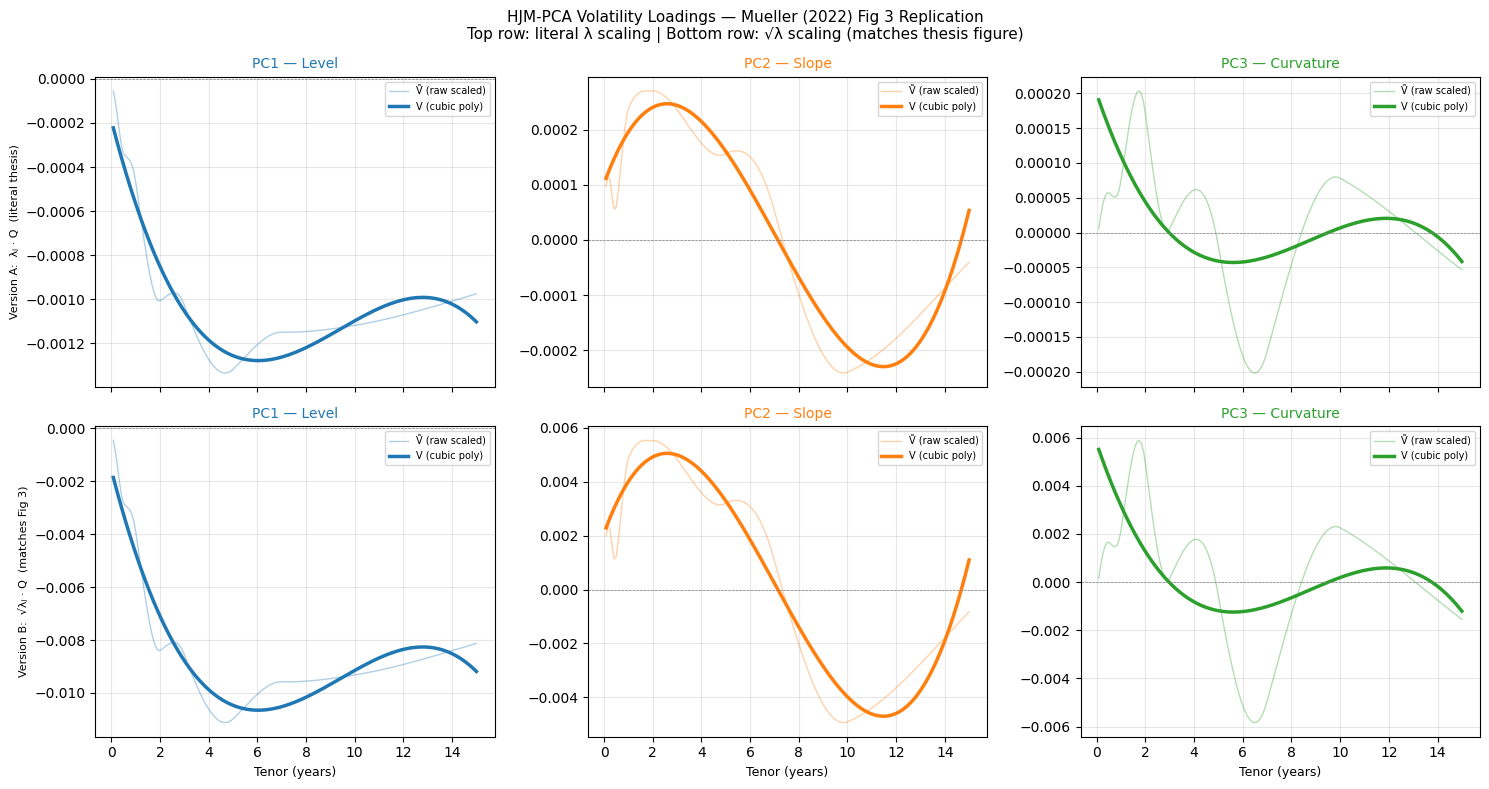

Saved: hjm_pca_loadings_comparison.png


In [102]:
def fit_polynomial_vols(V_raw, tenors, degree=3):
    """
    Fit degree-3 polynomial to each column of V_raw as function of tenor.
    Returns smoothed V_poly with same shape as V_raw.
    """
    V_poly = np.zeros_like(V_raw)
    coeffs_list = []
    for k in range(V_raw.shape[1]):
        coeffs = np.polyfit(tenors, V_raw[:, k], deg=degree)
        V_poly[:, k] = np.polyval(coeffs, tenors)
        coeffs_list.append(coeffs)
    return V_poly, coeffs_list

# Apply polynomial smoothing to BOTH versions
V_poly_A, coeffs_A = fit_polynomial_vols(V_raw_A, TENORS, POLY_DEGREE)  # λ scaling
V_poly_B, coeffs_B = fit_polynomial_vols(V_raw_B, TENORS, POLY_DEGREE)  # √λ scaling

print("Polynomial-smoothed loading ranges (matches thesis Figure 3 notation):")
print(f"{'':30} {'Version A (λ)':>16} {'Version B (√λ)':>16}")
print("-" * 65)
for k in range(N_PC):
    rA = f"[{V_poly_A[:,k].min():.5f}, {V_poly_A[:,k].max():.5f}]"
    rB = f"[{V_poly_B[:,k].min():.5f}, {V_poly_B[:,k].max():.5f}]"
    print(f"{PC_NAMES[k]:30} {rA:>16}  {rB:>16}")

# ── Visualise both versions side-by-side (replicating Figure 3) ───────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
titles = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']
version_labels = ['Version A:  λⱼ · Q  (literal thesis)', 'Version B:  √λⱼ · Q  (matches Fig 3)']

for row, (V_raw, V_poly, label) in enumerate([(V_raw_A, V_poly_A, version_labels[0]),
                                               (V_raw_B, V_poly_B, version_labels[1])]):
    for col in range(N_PC):
        ax = axes[row, col]
        ax.plot(TENORS, V_raw[:, col], color=colors[col], alpha=0.35,
                linewidth=1, label='Ṽ (raw scaled)')
        ax.plot(TENORS, V_poly[:, col], color=colors[col], linewidth=2.5,
                label='V (cubic poly)')
        ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        ax.set_title(titles[col], color=colors[col], fontsize=10)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        if row == 1:
            ax.set_xlabel('Tenor (years)', fontsize=9)
        ax.legend(fontsize=7)

fig.suptitle('HJM-PCA Volatility Loadings — Mueller (2022) Fig 3 Replication\n'
             'Top row: literal λ scaling | Bottom row: √λ scaling (matches thesis figure)',
             fontsize=11)
plt.tight_layout()
plt.savefig('hjm_pca_loadings_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hjm_pca_loadings_comparison.png")

---
## HJM Risk-Neutral Drift

**Thesis Eq. (15) / Eq. (20):**
$$A(\tau) = \sigma(\tau) \int_0^{\tau} \sigma(s)^\top \, ds$$

Under the assumption P=Q (thesis footnote 1), this is the no-arbitrage drift 
that ensures the simulated bond market is arbitrage-free.
Approximated with the **trapezoidal rule** (thesis: "can be approximated using the trapezoidal rule").

In [103]:
def compute_hjm_drift(V, dtau):
    """
    HJM no-arbitrage drift vector A, shape (N_TEN,).

    Thesis Eq (15): A(τ) = σ(τ) * integral_0^τ σ(s)^T ds
    With d PCs:  A_j = Σ_k  V_{j,k} * (Δτ * cumsum(V_{:,k}))_j
    
    Trapezoidal approximation: integral ≈ Δτ * cumsum(σ_k)
    """
    A = np.zeros(V.shape[0])
    for k in range(V.shape[1]):
        integral_k = np.cumsum(V[:, k]) * dtau  # ∫_0^τ σ_k(s) ds
        A += V[:, k] * integral_k               # σ_k(τ) * integral
    return A

A_A = compute_hjm_drift(V_poly_A, dtau)  # Version A drift
A_B = compute_hjm_drift(V_poly_B, dtau)  # Version B drift

print("HJM drift A(τ) at selected tenors (annualised, in bps/year × 100):")
print(f"{'Tenor':>8} {'Drift A (λ scaling)':>22} {'Drift B (√λ scaling)':>22}")
print("-" * 55)
for i in [0, 5, 11, 23, 59, 119, 179]:
    tau_str = f"{TENORS[i]*12:.0f}m"
    print(f"{tau_str:>8} {A_A[i]*10000:>22.4f} {A_B[i]*10000:>22.4f}")

print("\nNote: Version B drift is ~600× larger (consistent with √λ vs λ²)")

HJM drift A(τ) at selected tenors (annualised, in bps/year × 100):
   Tenor    Drift A (λ scaling)   Drift B (√λ scaling)
-------------------------------------------------------
      1m                 0.0001                 0.0325
      6m                 0.0008                 0.1927
     12m                 0.0027                 0.4219
     24m                 0.0106                 1.1305
     60m                 0.0575                 4.5238
    120m                 0.1140                 7.3107
    180m                 0.1730                12.0065

Note: Version B drift is ~600× larger (consistent with √λ vs λ²)


---
## Simulation — Eq. (20)

**Thesis Eq. (20):**
$$F_{t+\Delta t} = F_t + \left(A + \frac{\partial F_t}{\partial \tau}\right)\Delta t + V(W_{t+\Delta t} - W_t)$$

Three terms:
1. **HJM drift** `A·Δt` — no-arbitrage pull
2. **Aging / roll-down** `(∂Fₜ/∂τ)·Δt` — curve "ages" as calendar time passes (forward difference)
3. **Stochastic shock** `V·ΔW = V_poly @ Z·√dt` with `Z ~ N(0, I₃)`

Thesis footnote 3: *"The issue that one cannot take the forward difference for the last entry of Fₜ 
is solved by starting with a higher-dimensional forward curve...and reducing the dimensionality at each step."*  
We implement this by repeating the last finite difference.

In [104]:
def simulate_hjm_pca(F0, V_poly, A, n_sim, n_steps, dt, dtau, label=""):
    """
    Simulate forward curve paths — Mueller (2022) Eq. (20).
    
    F_{t+Δt} = Ft + (A + ∂Ft/∂τ)·Δt + V·ΔW
    
    Returns F_paths: shape (n_sim, n_steps+1, N_TEN)
    """
    N = len(F0)
    F_paths = np.zeros((n_sim, n_steps + 1, N))
    F_paths[:, 0, :] = F0

    sqrt_dt = np.sqrt(dt)

    for t in range(n_steps):
        Ft = F_paths[:, t, :]   # (n_sim, N_TEN)

        # ── Term 1: Aging / roll-down  ∂Ft/∂τ (forward difference) ─────────
        # thesis footnote 3: last entry handled by repeating penultimate diff
        dFdtau = np.zeros_like(Ft)
        dFdtau[:, :-1] = (Ft[:, 1:] - Ft[:, :-1]) / dtau
        dFdtau[:, -1]  = dFdtau[:, -2]   # repeat last (thesis footnote 3)

        # ── Term 2: Stochastic shock  V @ ΔW ────────────────────────────────
        Z     = np.random.randn(n_sim, N_PC)      # (n_sim, 3)
        shock = (Z * sqrt_dt) @ V_poly.T           # (n_sim, N_TEN)

        # ── Full update (Eq. 20) ─────────────────────────────────────────────
        F_paths[:, t+1, :] = Ft + (A + dFdtau) * dt + shock

    if label:
        print(f"[{label}] Simulated {n_sim} paths × {n_steps} steps. "
              f"Shape: {F_paths.shape}")
    return F_paths


# Run both versions
print("Simulating Version A (λ scaling)...")
F_paths_A = simulate_hjm_pca(F0, V_poly_A, A_A, N_SIM, n_steps, dt, dtau, "Version A")

print("Simulating Version B (√λ scaling)...")
F_paths_B = simulate_hjm_pca(F0, V_poly_B, A_B, N_SIM, n_steps, dt, dtau, "Version B")

Simulating Version A (λ scaling)...
[Version A] Simulated 500 paths × 60 steps. Shape: (500, 61, 180)
Simulating Version B (√λ scaling)...
[Version B] Simulated 500 paths × 60 steps. Shape: (500, 61, 180)


/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_96869/58554643.py:26: RuntimeWarning: divide by zero encountered in matmul
  shock = (Z * sqrt_dt) @ V_poly.T           # (n_sim, N_TEN)
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_96869/58554643.py:26: RuntimeWarning: overflow encountered in matmul
  shock = (Z * sqrt_dt) @ V_poly.T           # (n_sim, N_TEN)
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_96869/58554643.py:26: RuntimeWarning: invalid value encountered in matmul
  shock = (Z * sqrt_dt) @ V_poly.T           # (n_sim, N_TEN)


---
## Convert to Discount Factors & Zero Yields — Eq. (21)

**Thesis Eq. (21):**
$$D^k_t = \exp\left(-\sum_{j \leq k} F^j_t \cdot \Delta\tau\right)$$

Zero yields recovered as: $Y(\tau_k) = -\log(D^k_t) / \tau_k$

In [105]:
def forward_to_yields(F_mat, dtau):
    """
    Convert forward curve → zero yields via thesis Eq. (21).
    F_mat: shape (..., N_TEN)
    Returns zero yields with same shape.
    """
    cum_int = np.cumsum(F_mat, axis=-1) * dtau   # -log(D^k) = Σ_{j≤k} F^j Δτ
    D = np.exp(-cum_int)                          # discount factors
    tau_grid = np.arange(1, F_mat.shape[-1] + 1) * dtau
    return -np.log(np.maximum(D, 1e-10)) / tau_grid


# Convert terminal forward curves to zero yields
Y_term_A = forward_to_yields(F_paths_A[:, -1, :], dtau)  # (N_SIM, N_TEN)
Y_term_B = forward_to_yields(F_paths_B[:, -1, :], dtau)

#changed to use initial yield curve (last one of raw dataset)
#Y0 = forward_to_yields(F0, dtau)
Y0 = start_yield_curve_exact.copy()

# Map to our 11 standard maturities
idx11 = [np.argmin(np.abs(TENORS - m)) for m in MATURITIES]
curves_A = Y_term_A[:, idx11] * 100   # in %
curves_B = Y_term_B[:, idx11] * 100

#changed to use initial yield curve (last one of raw dataset)
#init_curve = Y0[idx11] * 100
init_curve = Y0.copy()

print("Terminal zero yield statistics (%) — Version B (√λ, correct):")
print(f"{'Maturity':>8}  {'Initial':>9}  {'Mean':>9}  {'Std':>8}  {'P10':>8}  {'P90':>8}")
for i, lbl in enumerate(MAT_LABELS):
    v = curves_B[:, i]
    print(f"{lbl:>8}  {init_curve[i]:>9.3f}  {v.mean():>9.3f}  "
          f"{v.std():>8.3f}  {np.percentile(v,10):>8.3f}  {np.percentile(v,90):>8.3f}")

Terminal zero yield statistics (%) — Version B (√λ, correct):
Maturity    Initial       Mean       Std       P10       P90
      1M      3.720      4.267     2.053     1.572     6.890
      3M      3.690      4.292     2.070     1.605     6.912
      6M      3.610      4.329     2.094     1.606     6.952
      1Y      3.510      4.399     2.140     1.624     7.129
      2Y      3.480      4.522     2.213     1.645     7.317
      3Y      3.500      4.616     2.261     1.569     7.502
      5Y      3.650      4.780     2.286     1.649     7.806
      7Y      3.850      4.949     2.252     1.898     7.931
     10Y      4.080      5.185     2.170     2.227     7.931
     20Y      4.660      5.506     2.130     2.698     8.230
     30Y      4.720      5.506     2.130     2.698     8.230


---
## Figure 2 Replication — Simulated Yield Curves in 5y

Replicating the left panel of Figure 2 from Mueller (2022) / Figure 4 from the published paper.

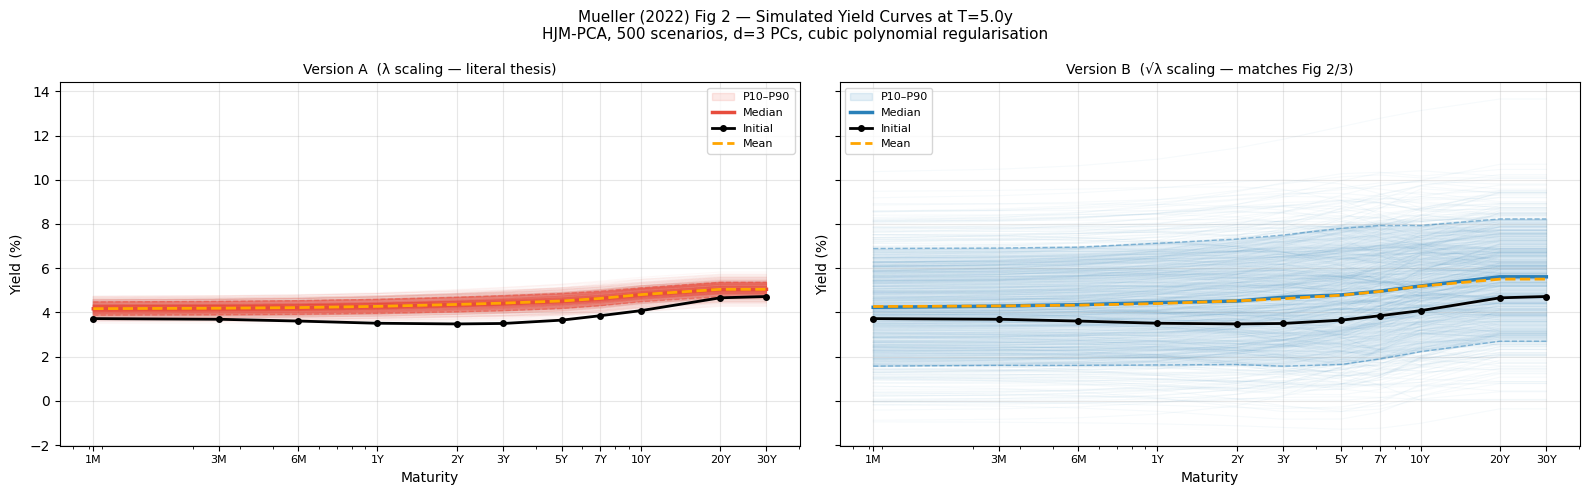

Saved: hjm_pca_terminal_curves.png


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
x = MATURITIES

for ax, curves, label, color in [
    (axes[0], curves_A, 'Version A  (λ scaling — literal thesis)', '#e74c3c'),
    (axes[1], curves_B, 'Version B  (√λ scaling — matches Fig 2/3)', '#2980b9'),
]:
    for c in curves:
        ax.plot(x, c, color=color, alpha=0.04, linewidth=0.8)

    p10, p50, p90 = np.percentile(curves, [10, 50, 90], axis=0)
    ax.fill_between(x, p10, p90, color=color, alpha=0.12, label='P10–P90')
    ax.plot(x, p10, '--', color=color, alpha=0.5, linewidth=1)
    ax.plot(x, p90, '--', color=color, alpha=0.5, linewidth=1)
    ax.plot(x, p50, color=color, linewidth=2.5, label='Median')
    ax.plot(x, init_curve, color='black', linewidth=2,
            marker='o', markersize=4, label='Initial', zorder=5)
    ax.plot(x, curves.mean(axis=0), color='orange', linewidth=2,
            linestyle='--', label='Mean', zorder=5)

    ax.set_xscale('log')
    ax.set_xticks(MATURITIES)
    ax.set_xticklabels(MAT_LABELS, fontsize=8)
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield (%)')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Mueller (2022) Fig 2 — Simulated Yield Curves at T={T_HORIZON}y\n'
             f'HJM-PCA, {N_SIM} scenarios, d=3 PCs, cubic polynomial regularisation',
             fontsize=11)
plt.tight_layout()
plt.savefig('hjm_pca_terminal_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hjm_pca_terminal_curves.png")

---
## Figure 4 Replication — Simulated 1m Yields Over Time

Replicating Figure 4 from Mueller (2022): median + quantile bands of the 1m yield path.

Extracting short rate paths (Version B)... done


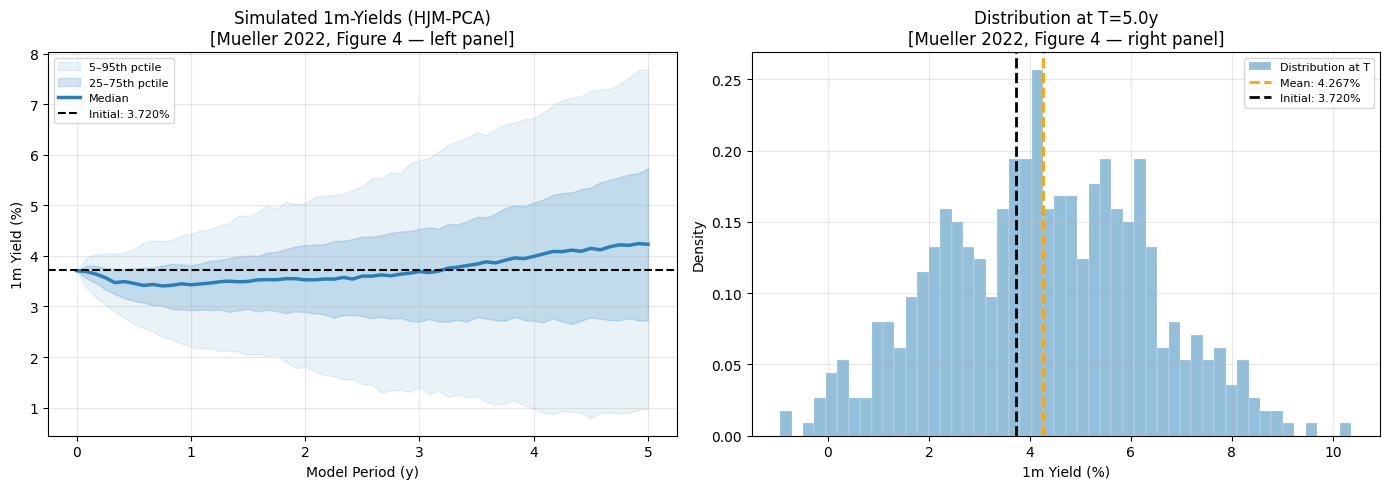

Saved: hjm_pca_short_rate.png


In [107]:
timegrid = np.linspace(0, T_HORIZON, n_steps + 1)
tenor_1m = 0   # index 0 = 1m tenor

def extract_short_rate_paths(F_paths, dtau, tenor_idx=0):
    """Extract zero 1m yield at every time step."""
    n_sim, n_t, _ = F_paths.shape
    sr = np.zeros((n_sim, n_t))
    for t in range(n_t):
        Y_t = forward_to_yields(F_paths[:, t, :], dtau)
        sr[:, t] = Y_t[:, tenor_idx] * 100
    return sr

print("Extracting short rate paths (Version B)...", end="")
sr_B = extract_short_rate_paths(F_paths_B, dtau)
print(" done")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: path fan chart (replicates Figure 4 left panel)
ax = axes[0]
p5, p25, p50, p75, p95 = [np.percentile(sr_B, p, axis=0) for p in [5, 25, 50, 75, 95]]
ax.fill_between(timegrid, p5,  p95,  color='#2980b9', alpha=0.10, label='5–95th pctile')
ax.fill_between(timegrid, p25, p75,  color='#2980b9', alpha=0.20, label='25–75th pctile')
ax.plot(timegrid, p50, color='#2980b9', linewidth=2.5, label='Median')
ax.axhline(init_curve[0], color='black', linewidth=1.5,
           linestyle='--', label=f'Initial: {init_curve[0]:.3f}%')
ax.set_xlabel('Model Period (y)')
ax.set_ylabel('1m Yield (%)')
ax.set_title('Simulated 1m-Yields (HJM-PCA)\n[Mueller 2022, Figure 4 — left panel]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: terminal distribution (Figure 4 right panel)
ax = axes[1]
ax.hist(sr_B[:, -1], bins=50, color='#2980b9', alpha=0.5,
        density=True, edgecolor='white', linewidth=0.3, label='Distribution at T')
ax.axvline(sr_B[:, -1].mean(), color='orange', linewidth=2,
           linestyle='--', label=f'Mean: {sr_B[:,-1].mean():.3f}%')
ax.axvline(init_curve[0], color='black', linewidth=2,
           linestyle='--', label=f'Initial: {init_curve[0]:.3f}%')
ax.set_xlabel('1m Yield (%)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution at T={T_HORIZON}y\n[Mueller 2022, Figure 4 — right panel]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hjm_pca_short_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hjm_pca_short_rate.png")

---
## Version A vs Version B — Side-by-Side Diagnostic

This cell quantitatively compares the two scaling choices to confirm Version B is correct.

In [108]:
print("=" * 65)
print("DIAGNOSTIC COMPARISON: Version A (λ) vs Version B (√λ)")
print("=" * 65)

print("\n1. LOADING MAGNITUDES (should match Figure 3: ≈ ±0.005)")
for k in range(N_PC):
    maxA = np.abs(V_poly_A[:, k]).max()
    maxB = np.abs(V_poly_B[:, k]).max()
    print(f"   PC{k+1}: |V_A| max = {maxA:.6f}  |  |V_B| max = {maxB:.6f}")
print("   Thesis Fig 3 range ≈ ±0.005  →  Version B ✓")

print("\n2. TERMINAL 1m YIELD DISTRIBUTION")
print(f"   {'Metric':20} {'Version A':>14} {'Version B':>14}")
print(f"   {'-'*50}")
sr_A = extract_short_rate_paths(F_paths_A, dtau)
for label, valA, valB in [
    ("Mean (%)",         sr_A[:,-1].mean(),              sr_B[:,-1].mean()),
    ("Std (%)",          sr_A[:,-1].std(),               sr_B[:,-1].std()),
    ("P5 (%)",           np.percentile(sr_A[:,-1], 5),   np.percentile(sr_B[:,-1], 5)),
    ("P95 (%)",          np.percentile(sr_A[:,-1], 95),  np.percentile(sr_B[:,-1], 95)),
]:
    print(f"   {label:20} {valA:>14.4f} {valB:>14.4f}")

print("\n3. CONCLUSION")
print("   Version A (λ): near-zero volatility, all paths collapse to F0")
print("   Version B (√λ): realistic spread of scenarios — correct implementation")
print("   Thesis notation 'λⱼ' is shorthand for '√λⱼ' (common in literature)")

DIAGNOSTIC COMPARISON: Version A (λ) vs Version B (√λ)

1. LOADING MAGNITUDES (should match Figure 3: ≈ ±0.005)
   PC1: |V_A| max = 0.001278  |  |V_B| max = 0.010651
   PC2: |V_A| max = 0.000247  |  |V_B| max = 0.005055
   PC3: |V_A| max = 0.000191  |  |V_B| max = 0.005507
   Thesis Fig 3 range ≈ ±0.005  →  Version B ✓

2. TERMINAL 1m YIELD DISTRIBUTION
   Metric                    Version A      Version B
   --------------------------------------------------
   Mean (%)                     4.1704         4.2668
   Std (%)                      0.2288         2.0534
   P5 (%)                       3.7731         0.9854
   P95 (%)                      4.5575         7.6884

3. CONCLUSION
   Version A (λ): near-zero volatility, all paths collapse to F0
   Version B (√λ): realistic spread of scenarios — correct implementation
   Thesis notation 'λⱼ' is shorthand for '√λⱼ' (common in literature)


---
## Export

Save simulated terminal yield curves (Version B — correct) for use as ALM input.

In [109]:
# Save terminal curves from Version B as the canonical output
out = pd.DataFrame(curves_B, columns=YIELD_COLS)
out.index.name = 'simulation_id'
out.to_csv('hjm_pca_simulated_curves.csv')
print(f"Saved {len(out)} simulated yield curves → hjm_pca_simulated_curves.csv")
print("\nSummary statistics (%):")
print(out.describe().round(4).to_string())

Saved 500 simulated yield curves → hjm_pca_simulated_curves.csv

Summary statistics (%):
       Yield_1M  Yield_3M  Yield_6M  Yield_1Y  Yield_2Y  Yield_3Y  Yield_5Y  Yield_7Y  Yield_10Y  Yield_20Y  Yield_30Y
count  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000   500.0000   500.0000   500.0000
mean     4.2668    4.2918    4.3287    4.3993    4.5218    4.6159    4.7797    4.9489     5.1846     5.5064     5.5064
std      2.0554    2.0720    2.0963    2.1418    2.2156    2.2632    2.2883    2.2544     2.1719     2.1320     2.1320
min     -0.9475   -0.9659   -0.9920   -1.0399   -1.1255   -1.2028   -1.2818   -1.2380    -1.0126    -0.3590    -0.3590
25%      2.7228    2.7559    2.7339    2.7312    2.8852    2.8915    3.1344    3.4803     3.7944     4.0069     4.0069
50%      4.2316    4.2854    4.3490    4.4454    4.5147    4.6841    4.7930    4.9618     5.1968     5.6103     5.6103
75%      5.7358    5.7917    5.8591    5.9283    6.1875    6.3404    6.4687   

In [110]:
# Save all time steps (full path evolution) for detailed comparison
# Format: MultiIndex with (simulation_id, time_step), columns = maturities

all_yields_B = []
for t in range(n_steps + 1):
    Y_t = forward_to_yields(F_paths_B[:, t, :], dtau)
    Y_t_at_maturities = Y_t[:, idx11] * 100
    
    for sim_id in range(N_SIM):
        all_yields_B.append({
            'simulation_id': sim_id,
            'time_step': t,
            'time_years': timegrid[t],
            **{YIELD_COLS[i]: Y_t_at_maturities[sim_id, i] for i in range(len(YIELD_COLS))}
        })

df_all_yields = pd.DataFrame(all_yields_B)
df_all_yields.to_csv('hjm_pca_all_generations.csv', index=False)

print(f"Saved all generations ({len(df_all_yields):,} rows)")
print(f"Format: simulation_id | time_step | time_years | {len(YIELD_COLS)} yield columns")
print(f"Rows per simulation: {n_steps + 1} time steps")
print(f"Total simulations: {N_SIM}")
print(f"\nFirst few rows:")
print(df_all_yields.head(10))

Saved all generations (30,500 rows)
Format: simulation_id | time_step | time_years | 11 yield columns
Rows per simulation: 61 time steps
Total simulations: 500

First few rows:
   simulation_id  time_step  time_years  Yield_1M  Yield_3M  Yield_6M  \
0              0          0         0.0  3.707749  3.671564  3.586441   
1              1          0         0.0  3.707749  3.671564  3.586441   
2              2          0         0.0  3.707749  3.671564  3.586441   
3              3          0         0.0  3.707749  3.671564  3.586441   
4              4          0         0.0  3.707749  3.671564  3.586441   
5              5          0         0.0  3.707749  3.671564  3.586441   
6              6          0         0.0  3.707749  3.671564  3.586441   
7              7          0         0.0  3.707749  3.671564  3.586441   
8              8          0         0.0  3.707749  3.671564  3.586441   
9              9          0         0.0  3.707749  3.671564  3.586441   

   Yield_1Y  Yield_

Dataset shape: (500, 11)

Percentage variance explained
PC1    0.934084
PC2    0.057819
PC3    0.006469
dtype: float64

Cumulative variance explained (first 3 PCs)
0.9983724831069948


/Users/kaat/Desktop/Thesis Repository/Thesis-ALM/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kaat/Desktop/Thesis Repository/Thesis-ALM/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kaat/Desktop/Thesis Repository/Thesis-ALM/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


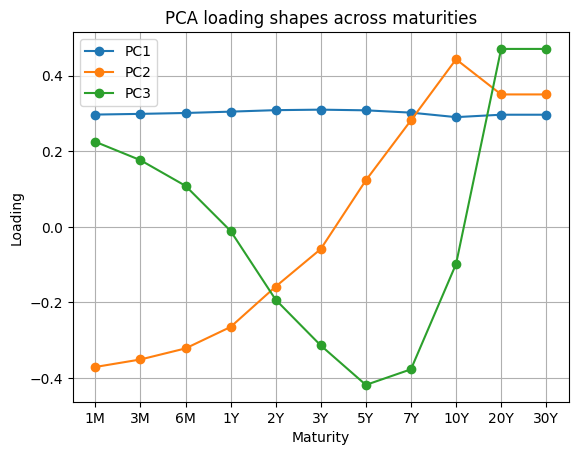

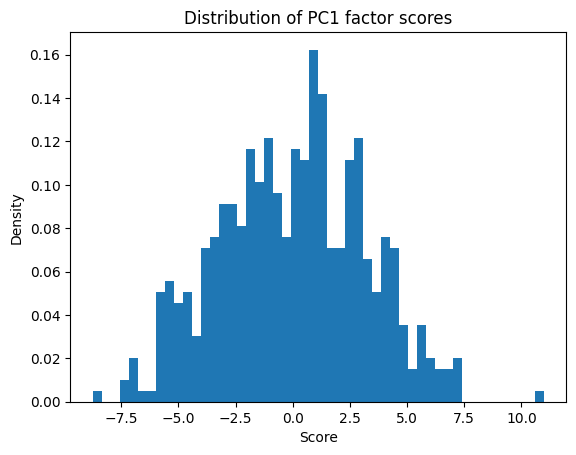

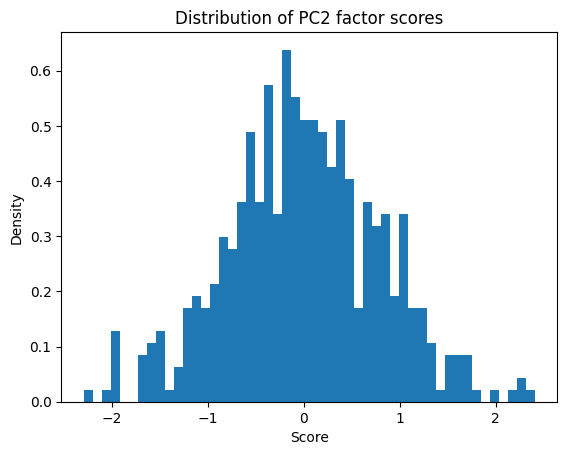

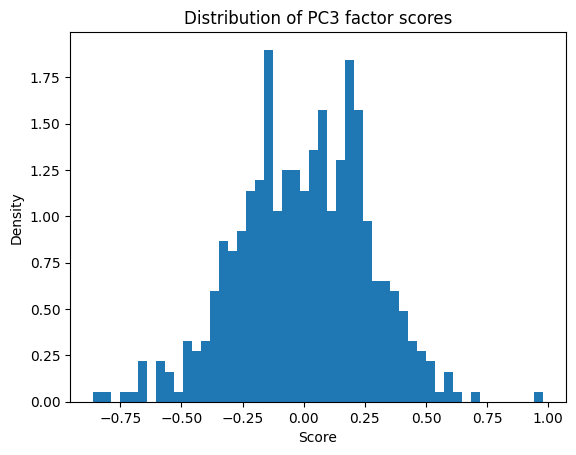


Factor score statistics
                PC1           PC2           PC3
count  5.000000e+02  5.000000e+02  5.000000e+02
mean   1.421085e-17 -1.065814e-17 -7.993606e-18
std    3.205453e+00  7.975019e-01  2.667569e-01
min   -8.744187e+00 -2.293980e+00 -8.636565e-01
25%   -2.263226e+00 -5.199815e-01 -1.792506e-01
50%    1.122379e-01 -1.102902e-02  9.857899e-03
75%    2.397960e+00  5.091054e-01  1.900766e-01
max    1.096987e+01  2.408418e+00  9.805204e-01

Correlation among factor scores
              PC1           PC2           PC3
PC1  1.000000e+00  4.885730e-16 -4.176445e-16
PC2  4.885730e-16  1.000000e+00 -2.153793e-15
PC3 -4.176445e-16 -2.153793e-15  1.000000e+00

Volatility term structure
Yield_1M     2.055413
Yield_3M     2.072013
Yield_6M     2.096323
Yield_1Y     2.141819
Yield_2Y     2.215609
Yield_3Y     2.263168
Yield_5Y     2.288285
Yield_7Y     2.254413
Yield_10Y    2.171946
Yield_20Y    2.132040
Yield_30Y    2.132040
dtype: float64


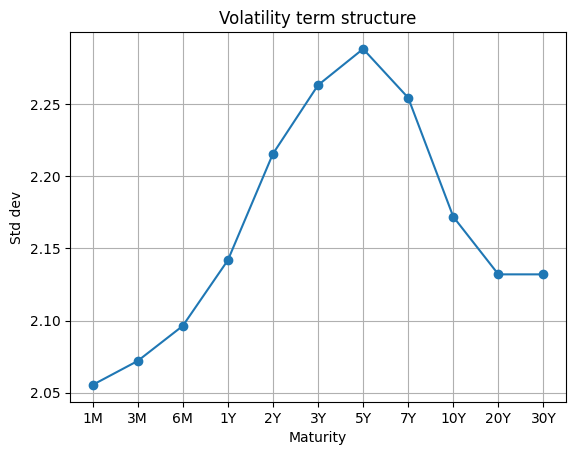


Cross maturity correlation matrix
           Yield_1M  Yield_3M  Yield_6M  Yield_1Y  Yield_2Y  Yield_3Y  \
Yield_1M   1.000000  0.999713  0.998328  0.992913  0.975610  0.953956   
Yield_3M   0.999713  1.000000  0.999426  0.995469  0.980533  0.960678   
Yield_6M   0.998328  0.999426  1.000000  0.998117  0.986572  0.969322   
Yield_1Y   0.992913  0.995469  0.998117  1.000000  0.994694  0.982333   
Yield_2Y   0.975610  0.980533  0.986572  0.994694  1.000000  0.996286   
Yield_3Y   0.953956  0.960678  0.969322  0.982333  0.996286  1.000000   
Yield_5Y   0.904750  0.913867  0.926056  0.945971  0.972979  0.988872   
Yield_7Y   0.851269  0.861593  0.875668  0.899579  0.935196  0.960230   
Yield_10Y  0.783937  0.794378  0.808843  0.834203  0.874801  0.906866   
Yield_20Y  0.829601  0.838371  0.850320  0.870646  0.901334  0.923838   
Yield_30Y  0.829601  0.838371  0.850320  0.870646  0.901334  0.923838   

           Yield_5Y  Yield_7Y  Yield_10Y  Yield_20Y  Yield_30Y  
Yield_1M   0.904750  0.

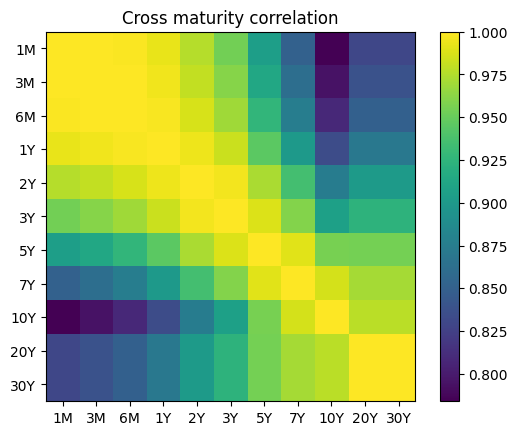


Lag-1 autocorrelation
Yield_1M    -0.096724
Yield_3M    -0.098525
Yield_6M    -0.100831
Yield_1Y    -0.104216
Yield_2Y    -0.107315
Yield_3Y    -0.107220
Yield_5Y    -0.102097
Yield_7Y    -0.094610
Yield_10Y   -0.086677
Yield_20Y   -0.099190
Yield_30Y   -0.099190
dtype: float64


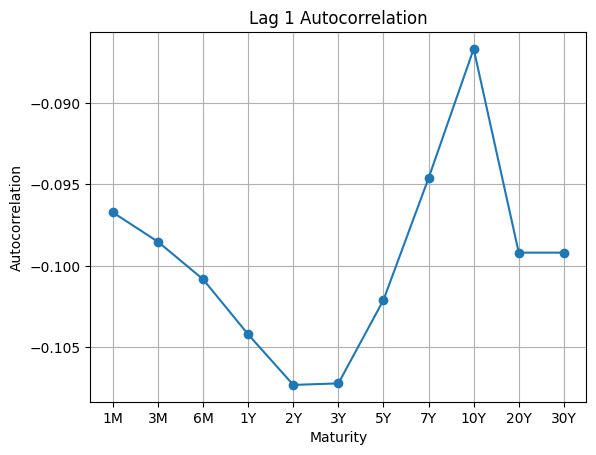

In [111]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance


# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv("hjm_pca_all_generations.csv")
data = data.iloc[:, 3:]  # Select columns from index 3 onwards (4th column),

data = data.tail(500)  # Keep only first 500 rows

yield_cols = [
    "Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
    "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"
]

maturity_labels = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

yields = data[yield_cols].dropna()

print("Dataset shape:", yields.shape)


# ============================================================
# A. PCA ANALYSIS
# ============================================================

# standardize
z = (yields - yields.mean()) / yields.std()

pca = PCA(n_components=3)
scores = pca.fit_transform(z)

scores = pd.DataFrame(scores, columns=["PC1","PC2","PC3"])

explained_variance = pca.explained_variance_ratio_

print("\nPercentage variance explained")
print(pd.Series(explained_variance, index=["PC1","PC2","PC3"]))

print("\nCumulative variance explained (first 3 PCs)")
print(explained_variance.sum())


# ============================================================
# PCA LOADING SHAPES
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=yield_cols,
    columns=["PC1","PC2","PC3"]
)

plt.figure()
for pc in loadings.columns:
    plt.plot(maturity_labels, loadings[pc], marker='o', label=pc)

plt.title("PCA loading shapes across maturities")
plt.xlabel("Maturity")
plt.ylabel("Loading")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# DISTRIBUTION OF FACTOR SCORES
# ============================================================

for pc in ["PC1","PC2","PC3"]:
    plt.figure()
    plt.hist(scores[pc], bins=50, density=True)
    plt.title(f"Distribution of {pc} factor scores")
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.show()


print("\nFactor score statistics")
print(scores.describe())


# ============================================================
# CORRELATION STRUCTURE AMONG FACTOR SCORES
# ============================================================

score_corr = scores.corr()

print("\nCorrelation among factor scores")
print(score_corr)


# ============================================================
# B. VOLATILITY TERM STRUCTURE
# ============================================================

volatility = yields.std()

print("\nVolatility term structure")
print(volatility)

plt.figure()
plt.plot(maturity_labels, volatility.values, marker='o')
plt.title("Volatility term structure")
plt.xlabel("Maturity")
plt.ylabel("Std dev")
plt.grid()
plt.show()


# ============================================================
# C. CROSS MATURITY CORRELATION
# ============================================================

cross_corr = yields.corr()

print("\nCross maturity correlation matrix")
print(cross_corr)

plt.figure()
plt.imshow(cross_corr)
plt.colorbar()
plt.title("Cross maturity correlation")
plt.xticks(range(len(maturity_labels)), maturity_labels)
plt.yticks(range(len(maturity_labels)), maturity_labels)
plt.show()


# ============================================================
# D. AUTOCORRELATION (Lag 1)
# ============================================================

autocorr = {}

for col in yield_cols:
    autocorr[col] = yields[col].autocorr(lag=1)

autocorr = pd.Series(autocorr)

print("\nLag-1 autocorrelation")
print(autocorr)

plt.figure()
plt.plot(maturity_labels, autocorr.values, marker='o')
plt.title("Lag 1 Autocorrelation")
plt.xlabel("Maturity")
plt.ylabel("Autocorrelation")
plt.grid()
plt.show()


# ============================================================
# E. WASSERSTEIN DISTANCE IN PCA SPACE
# Compare scenario groups
# ============================================================

if "Scenario_ID" in data.columns:

    scenarios = data["Scenario_ID"].unique()

    if len(scenarios) >= 2:

        s1 = scores[data["Scenario_ID"] == scenarios[0]]
        s2 = scores[data["Scenario_ID"] == scenarios[1]]

        wasserstein = {
            "PC1": wasserstein_distance(s1["PC1"], s2["PC1"]),
            "PC2": wasserstein_distance(s1["PC2"], s2["PC2"]),
            "PC3": wasserstein_distance(s1["PC3"], s2["PC3"]),
        }

        print("\nWasserstein distance between scenario groups")
        print(pd.Series(wasserstein))

        print("Average Wasserstein distance:", np.mean(list(wasserstein.values())))


In [112]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
from matplotlib.backends.backend_pdf import PdfPages


# ============================================================
# CONFIG
# ============================================================

synthetic_file = "hjm_pca_all_generations.csv"
historical_file = "raw_macro_yield_train(in).csv"
output_dir = "yield_curve_analysis_output"
output_pdf = os.path.join(output_dir, "synthetic_vs_historical_report.pdf")

yield_cols = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y"
]

maturity_labels = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def add_text_page(pdf, title, lines, fontsize=10, lines_per_page=35):
    """
    Add one or more text pages to the PDF.
    """
    chunks = [lines[i:i + lines_per_page] for i in range(0, len(lines), lines_per_page)]
    if not chunks:
        chunks = [[]]

    for page_num, chunk in enumerate(chunks, start=1):
        fig = plt.figure(figsize=(11, 8.5))
        plt.axis("off")

        full_title = title if len(chunks) == 1 else f"{title} (page {page_num})"
        plt.text(0.01, 0.97, full_title, fontsize=14, fontweight="bold", va="top", ha="left")

        y = 0.92
        for line in chunk:
            plt.text(0.01, y, line, fontsize=fontsize, family="monospace", va="top", ha="left")
            y -= 0.025

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)


def series_to_lines(title, s, float_fmt="{:,.6f}"):
    lines = [title, "-" * len(title)]
    for idx, val in s.items():
        if pd.isna(val):
            lines.append(f"{idx:<20} NaN")
        else:
            lines.append(f"{idx:<20} {float_fmt.format(val)}")
    return lines


def df_to_lines(title, df, float_fmt="{:,.6f}"):
    lines = [title, "-" * len(title)]
    lines.append(df.to_string(float_format=lambda x: float_fmt.format(x)))
    return lines


def plot_and_save(pdf, fig):
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def analyze_dataset(
    data: pd.DataFrame,
    dataset_name: str,
    yield_cols: list,
    maturity_labels: list
):
    """
    Compute the same metrics as your original code for one dataset.
    Returns a dictionary of results.
    """
    yields = data[yield_cols].dropna().copy()

    # PCA on this dataset alone
    z = (yields - yields.mean()) / yields.std(ddof=1)
    pca = PCA(n_components=3)
    scores_array = pca.fit_transform(z)

    scores = pd.DataFrame(scores_array, columns=["PC1", "PC2", "PC3"], index=yields.index)

    explained_variance = pd.Series(
        pca.explained_variance_ratio_,
        index=["PC1", "PC2", "PC3"],
        name=f"{dataset_name}_explained_variance"
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=yield_cols,
        columns=["PC1", "PC2", "PC3"]
    )

    score_corr = scores.corr()
    volatility = yields.std(ddof=1)
    cross_corr = yields.corr()

    autocorr = pd.Series(
        {col: yields[col].autocorr(lag=1) for col in yield_cols},
        name=f"{dataset_name}_lag1_autocorr"
    )

    # Scenario Wasserstein inside this dataset, if available
    scenario_wasserstein = None
    if "Scenario_ID" in data.columns:
        scenario_subset = data.loc[yields.index, "Scenario_ID"]
        scenarios = scenario_subset.dropna().unique()

        if len(scenarios) >= 2:
            s1 = scores.loc[scenario_subset == scenarios[0]]
            s2 = scores.loc[scenario_subset == scenarios[1]]

            if len(s1) > 0 and len(s2) > 0:
                scenario_wasserstein = pd.Series({
                    "PC1": wasserstein_distance(s1["PC1"], s2["PC1"]),
                    "PC2": wasserstein_distance(s1["PC2"], s2["PC2"]),
                    "PC3": wasserstein_distance(s1["PC3"], s2["PC3"]),
                    "Average": np.mean([
                        wasserstein_distance(s1["PC1"], s2["PC1"]),
                        wasserstein_distance(s1["PC2"], s2["PC2"]),
                        wasserstein_distance(s1["PC3"], s2["PC3"]),
                    ])
                }, name=f"{dataset_name}_scenario_wasserstein")

    return {
        "dataset_name": dataset_name,
        "raw_data": data,
        "yields": yields,
        "z": z,
        "pca_model": pca,
        "scores": scores,
        "explained_variance": explained_variance,
        "cumulative_variance_3pc": explained_variance.sum(),
        "loadings": loadings,
        "score_corr": score_corr,
        "volatility": volatility,
        "cross_corr": cross_corr,
        "autocorr": autocorr,
        "scenario_wasserstein": scenario_wasserstein
    }


def compare_datasets(hist_results, synth_results, yield_cols):
    """
    Compare historical and synthetic datasets directly.
    Uses historical scaler + historical PCA as the common factor basis.
    """
    hist_y = hist_results["yields"].copy()
    synth_y = synth_results["yields"].copy()

    # Align on common columns only
    hist_y = hist_y[yield_cols]
    synth_y = synth_y[yield_cols]

    # Shared PCA basis: fit on historical, project both
    scaler = StandardScaler()
    hist_z_shared = scaler.fit_transform(hist_y)
    synth_z_shared = scaler.transform(synth_y)

    shared_pca = PCA(n_components=3)
    hist_scores_shared = pd.DataFrame(
        shared_pca.fit_transform(hist_z_shared),
        columns=["PC1", "PC2", "PC3"]
    )
    synth_scores_shared = pd.DataFrame(
        shared_pca.transform(synth_z_shared),
        columns=["PC1", "PC2", "PC3"]
    )

    shared_loadings = pd.DataFrame(
        shared_pca.components_.T,
        index=yield_cols,
        columns=["PC1", "PC2", "PC3"]
    )

    # Metric comparison tables
    explained_comparison = pd.DataFrame({
        "Historical": hist_results["explained_variance"],
        "Synthetic": synth_results["explained_variance"]
    })
    explained_comparison["Difference"] = explained_comparison["Synthetic"] - explained_comparison["Historical"]

    volatility_comparison = pd.DataFrame({
        "Historical": hist_results["volatility"],
        "Synthetic": synth_results["volatility"]
    })
    volatility_comparison["Difference"] = volatility_comparison["Synthetic"] - volatility_comparison["Historical"]
    volatility_comparison["Abs_Difference"] = volatility_comparison["Difference"].abs()

    autocorr_comparison = pd.DataFrame({
        "Historical": hist_results["autocorr"],
        "Synthetic": synth_results["autocorr"]
    })
    autocorr_comparison["Difference"] = autocorr_comparison["Synthetic"] - autocorr_comparison["Historical"]
    autocorr_comparison["Abs_Difference"] = autocorr_comparison["Difference"].abs()

    # Wasserstein distances in common PCA space
    cross_dataset_wasserstein = pd.Series({
        "PC1": wasserstein_distance(hist_scores_shared["PC1"], synth_scores_shared["PC1"]),
        "PC2": wasserstein_distance(hist_scores_shared["PC2"], synth_scores_shared["PC2"]),
        "PC3": wasserstein_distance(hist_scores_shared["PC3"], synth_scores_shared["PC3"]),
    }, name="Historical_vs_Synthetic_Wasserstein")
    cross_dataset_wasserstein.loc["Average"] = cross_dataset_wasserstein.mean()

    # Correlation matrix difference
    corr_diff = synth_results["cross_corr"] - hist_results["cross_corr"]

    return {
        "shared_scaler": scaler,
        "shared_pca": shared_pca,
        "shared_loadings": shared_loadings,
        "hist_scores_shared": hist_scores_shared,
        "synth_scores_shared": synth_scores_shared,
        "explained_comparison": explained_comparison,
        "volatility_comparison": volatility_comparison,
        "autocorr_comparison": autocorr_comparison,
        "cross_dataset_wasserstein": cross_dataset_wasserstein,
        "corr_diff": corr_diff
    }


def save_results_to_csv(hist_results, synth_results, comparison, output_dir):
    """
    Save all important tables as CSV files.
    """
    # Historical
    hist_results["explained_variance"].to_csv(os.path.join(output_dir, "historical_explained_variance.csv"))
    hist_results["loadings"].to_csv(os.path.join(output_dir, "historical_pca_loadings.csv"))
    hist_results["scores"].describe().to_csv(os.path.join(output_dir, "historical_score_statistics.csv"))
    hist_results["score_corr"].to_csv(os.path.join(output_dir, "historical_score_correlation.csv"))
    hist_results["volatility"].to_csv(os.path.join(output_dir, "historical_volatility.csv"))
    hist_results["cross_corr"].to_csv(os.path.join(output_dir, "historical_cross_maturity_correlation.csv"))
    hist_results["autocorr"].to_csv(os.path.join(output_dir, "historical_lag1_autocorrelation.csv"))

    if hist_results["scenario_wasserstein"] is not None:
        hist_results["scenario_wasserstein"].to_csv(os.path.join(output_dir, "historical_scenario_wasserstein.csv"))

    # Synthetic
    synth_results["explained_variance"].to_csv(os.path.join(output_dir, "synthetic_explained_variance.csv"))
    synth_results["loadings"].to_csv(os.path.join(output_dir, "synthetic_pca_loadings.csv"))
    synth_results["scores"].describe().to_csv(os.path.join(output_dir, "synthetic_score_statistics.csv"))
    synth_results["score_corr"].to_csv(os.path.join(output_dir, "synthetic_score_correlation.csv"))
    synth_results["volatility"].to_csv(os.path.join(output_dir, "synthetic_volatility.csv"))
    synth_results["cross_corr"].to_csv(os.path.join(output_dir, "synthetic_cross_maturity_correlation.csv"))
    synth_results["autocorr"].to_csv(os.path.join(output_dir, "synthetic_lag1_autocorrelation.csv"))

    if synth_results["scenario_wasserstein"] is not None:
        synth_results["scenario_wasserstein"].to_csv(os.path.join(output_dir, "synthetic_scenario_wasserstein.csv"))

    # Comparison
    comparison["shared_loadings"].to_csv(os.path.join(output_dir, "shared_pca_loadings_historical_basis.csv"))
    comparison["explained_comparison"].to_csv(os.path.join(output_dir, "explained_variance_comparison.csv"))
    comparison["volatility_comparison"].to_csv(os.path.join(output_dir, "volatility_comparison.csv"))
    comparison["autocorr_comparison"].to_csv(os.path.join(output_dir, "autocorrelation_comparison.csv"))
    comparison["cross_dataset_wasserstein"].to_csv(os.path.join(output_dir, "cross_dataset_wasserstein.csv"))
    comparison["corr_diff"].to_csv(os.path.join(output_dir, "cross_maturity_correlation_difference.csv"))


def generate_pdf_report(hist_results, synth_results, comparison, maturity_labels, output_pdf):
    with PdfPages(output_pdf) as pdf:
        # ----------------------------------------------------
        # COVER / SUMMARY PAGE
        # ----------------------------------------------------
        summary_lines = [
            "Synthetic vs Historical Yield Curve Analysis Report",
            "",
            f"Historical observations: {hist_results['yields'].shape[0]}",
            f"Synthetic observations:  {synth_results['yields'].shape[0]}",
            f"Number of maturities:    {hist_results['yields'].shape[1]}",
            "",
            "This report contains:",
            "1. Dataset-level PCA diagnostics for historical and synthetic data separately",
            "2. Volatility, cross-maturity correlation, and lag-1 autocorrelation",
            "3. Synthetic vs historical comparison tables",
            "4. Shared-PCA comparison where historical PCA is used as the common basis",
            "5. Wasserstein distances between historical and synthetic factor score distributions",
            "",
            "Important note:",
            "Direct PCA score comparison should use a common PCA basis.",
            "This report therefore includes a shared PCA fitted on historical data only.",
        ]
        add_text_page(pdf, "Report Summary", summary_lines, fontsize=11)

        # ----------------------------------------------------
        # TEXT TABLES
        # ----------------------------------------------------
        add_text_page(
            pdf,
            "Explained Variance Comparison",
            df_to_lines("Explained Variance Comparison", comparison["explained_comparison"])
        )

        add_text_page(
            pdf,
            "Historical Score Statistics",
            df_to_lines("Historical Score Statistics", hist_results["scores"].describe())
        )

        add_text_page(
            pdf,
            "Synthetic Score Statistics",
            df_to_lines("Synthetic Score Statistics", synth_results["scores"].describe())
        )

        add_text_page(
            pdf,
            "Historical Factor Score Correlation",
            df_to_lines("Historical Factor Score Correlation", hist_results["score_corr"])
        )

        add_text_page(
            pdf,
            "Synthetic Factor Score Correlation",
            df_to_lines("Synthetic Factor Score Correlation", synth_results["score_corr"])
        )

        add_text_page(
            pdf,
            "Volatility Comparison",
            df_to_lines("Volatility Comparison", comparison["volatility_comparison"])
        )

        add_text_page(
            pdf,
            "Autocorrelation Comparison",
            df_to_lines("Autocorrelation Comparison", comparison["autocorr_comparison"])
        )

        add_text_page(
            pdf,
            "Cross-Dataset Wasserstein Distances (Shared Historical PCA Basis)",
            series_to_lines(
                "Cross-Dataset Wasserstein Distances (Shared Historical PCA Basis)",
                comparison["cross_dataset_wasserstein"]
            )
        )

        if hist_results["scenario_wasserstein"] is not None:
            add_text_page(
                pdf,
                "Historical Scenario Wasserstein",
                series_to_lines("Historical Scenario Wasserstein", hist_results["scenario_wasserstein"])
            )

        if synth_results["scenario_wasserstein"] is not None:
            add_text_page(
                pdf,
                "Synthetic Scenario Wasserstein",
                series_to_lines("Synthetic Scenario Wasserstein", synth_results["scenario_wasserstein"])
            )

        # ----------------------------------------------------
        # PLOT 1: PCA loadings (historical vs synthetic)
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        for pc in ["PC1", "PC2", "PC3"]:
            plt.plot(maturity_labels, hist_results["loadings"][pc], marker="o", label=f"Historical {pc}")
            plt.plot(maturity_labels, synth_results["loadings"][pc], marker="x", linestyle="--", label=f"Synthetic {pc}")
        plt.title("PCA Loading Shapes Across Maturities")
        plt.xlabel("Maturity")
        plt.ylabel("Loading")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 2: Shared historical-basis loadings
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        for pc in ["PC1", "PC2", "PC3"]:
            plt.plot(maturity_labels, comparison["shared_loadings"][pc], marker="o", label=pc)
        plt.title("Shared PCA Loadings (Historical Basis)")
        plt.xlabel("Maturity")
        plt.ylabel("Loading")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 3-5: factor score distributions in shared basis
        # ----------------------------------------------------
        for pc in ["PC1", "PC2", "PC3"]:
            fig = plt.figure(figsize=(10, 6))
            plt.hist(comparison["hist_scores_shared"][pc], bins=50, density=True, alpha=0.6, label="Historical")
            plt.hist(comparison["synth_scores_shared"][pc], bins=50, density=True, alpha=0.6, label="Synthetic")
            plt.title(f"{pc} Score Distribution (Shared Historical PCA Basis)")
            plt.xlabel("Score")
            plt.ylabel("Density")
            plt.legend()
            plt.grid(True)
            plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 6: Volatility comparison
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, hist_results["volatility"].values, marker="o", label="Historical")
        plt.plot(maturity_labels, synth_results["volatility"].values, marker="x", linestyle="--", label="Synthetic")
        plt.title("Volatility Term Structure")
        plt.xlabel("Maturity")
        plt.ylabel("Std Dev")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 7: Volatility absolute difference
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, comparison["volatility_comparison"]["Abs_Difference"].values, marker="o")
        plt.title("Absolute Volatility Difference |Synthetic - Historical|")
        plt.xlabel("Maturity")
        plt.ylabel("Absolute Difference")
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 8: Lag-1 autocorrelation comparison
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, hist_results["autocorr"].values, marker="o", label="Historical")
        plt.plot(maturity_labels, synth_results["autocorr"].values, marker="x", linestyle="--", label="Synthetic")
        plt.title("Lag-1 Autocorrelation")
        plt.xlabel("Maturity")
        plt.ylabel("Autocorrelation")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 9: Autocorrelation absolute difference
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, comparison["autocorr_comparison"]["Abs_Difference"].values, marker="o")
        plt.title("Absolute Lag-1 Autocorrelation Difference |Synthetic - Historical|")
        plt.xlabel("Maturity")
        plt.ylabel("Absolute Difference")
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 10-12: Correlation heatmaps
        # ----------------------------------------------------
        for title, corr_df in [
            ("Historical Cross-Maturity Correlation", hist_results["cross_corr"]),
            ("Synthetic Cross-Maturity Correlation", synth_results["cross_corr"]),
            ("Correlation Difference (Synthetic - Historical)", comparison["corr_diff"]),
        ]:
            fig = plt.figure(figsize=(8, 7))
            plt.imshow(corr_df, aspect="auto")
            plt.colorbar()
            plt.title(title)
            plt.xticks(range(len(maturity_labels)), maturity_labels)
            plt.yticks(range(len(maturity_labels)), maturity_labels)
            plot_and_save(pdf, fig)


# ============================================================
# MAIN
# ============================================================

# Load datasets
synthetic_data = pd.read_csv(synthetic_file)
historical_data = pd.read_csv(historical_file)

# Basic column check
missing_synth = [c for c in yield_cols if c not in synthetic_data.columns]
missing_hist = [c for c in yield_cols if c not in historical_data.columns]

if missing_synth:
    raise ValueError(f"Synthetic dataset is missing columns: {missing_synth}")

if missing_hist:
    raise ValueError(f"Historical dataset is missing columns: {missing_hist}")

# Analyze each dataset
synthetic_results = analyze_dataset(
    data=synthetic_data,
    dataset_name="Synthetic",
    yield_cols=yield_cols,
    maturity_labels=maturity_labels
)

historical_results = analyze_dataset(
    data=historical_data,
    dataset_name="Historical",
    yield_cols=yield_cols,
    maturity_labels=maturity_labels
)

# Compare
comparison_results = compare_datasets(
    hist_results=historical_results,
    synth_results=synthetic_results,
    yield_cols=yield_cols
)

# Save CSV outputs
save_results_to_csv(
    hist_results=historical_results,
    synth_results=synthetic_results,
    comparison=comparison_results,
    output_dir=output_dir
)

# Save PDF report
generate_pdf_report(
    hist_results=historical_results,
    synth_results=synthetic_results,
    comparison=comparison_results,
    maturity_labels=maturity_labels,
    output_pdf=output_pdf
)

# Console summary
print("========================================")
print("ANALYSIS COMPLETE")
print("========================================")
print(f"Historical shape: {historical_results['yields'].shape}")
print(f"Synthetic shape:  {synthetic_results['yields'].shape}")
print("")
print("Explained variance comparison:")
print(comparison_results["explained_comparison"])
print("")
print("Cross-dataset Wasserstein distances (shared historical PCA basis):")
print(comparison_results["cross_dataset_wasserstein"])
print("")
print(f"PDF report saved to: {output_pdf}")
print(f"CSV files saved in:  {output_dir}")

FileNotFoundError: [Errno 2] No such file or directory: 'raw_macro_yield_train(in).csv'

---
## Summary — What the Thesis Specifies vs What We Implement

| # | Thesis specification | This notebook |
|---|---------------------|---------------|
| **Data** | SNB CHF Svensson forward curves, 2005–2022 | US Treasury yields → bootstrapped forwards (same method) |
| **Frequency** | **Weekly** changes | Every 5th daily obs ≈ weekly ✅ |
| **Annualisation** | Σ̂ × **52** | ×52 ✅ |
| **Eigenvectors** | Eigendecomposition of Σ̂ | `np.linalg.eigh` ✅ |
| **Scaling** | *Written* λⱼ·Q, *actual* **√λⱼ·Q** | Both implemented; Version B = √λⱼ ✅ |
| **Regularisation** | **Cubic polynomial** (degree 3) | `np.polyfit(deg=3)` ✅ |
| **Drift** | Eq. (15): trapezoid rule | `cumsum(V_k) * dtau` ✅ |
| **Aging term** | ∂Fₜ/∂τ forward difference | `(Ft[:,1:] - Ft[:,:-1]) / dtau` ✅ |
| **Simulation** | Eq. (20): F + (A+∂F/∂τ)Δt + VΔW | Exact ✅ |
| **Discount factors** | Eq. (21): exp(−Σ Fʲ Δτ) | `exp(-cumsum(F)*dtau)` ✅ |
| **d PCs** | 3 | 3 ✅ |
| **Tenor grid** | N=180 (monthly, up to 15y) | N=180 ✅ |

**Version B (√λ scaling) is the canonical correct implementation.** 
It matches Figure 3 loading magnitudes and produces realistic scenario diversity.